In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import quantus
from sklearn.model_selection import train_test_split
import os
import h5py
import os
import librosa
from tensorflow.keras import layers, models, optimizers



2024-07-16 20:58:57.083128: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-16 20:58:57.253029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-16 20:58:57.294965: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-16 20:58:57.300880: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-16 20:58:57.364993: I tensorflow/core/platform/cpu_feature_guar

In [2]:
from sklearn.model_selection import train_test_split
import os
import h5py
import os
import librosa
from tensorflow.keras import layers, models, optimizers


In [3]:
def load_preprocessed_data(data_path):
    X = []
    y = []
    for root, _, files in os.walk(data_path):
        for file in files:
            if file.startswith('AlexNet') and file.endswith('.hdf5'):
                file_path = os.path.join(root, file)
                with h5py.File(file_path, 'r') as f:
                    X.append(f['data'][:])
                    y.append(f['label'][:, 0])  # Only take the digit label, not gender
    return np.concatenate(X, axis=0), np.concatenate(y, axis=0)

In [4]:
# Load preprocessed data
data_path = '/home/mqa887/tmp/audiomnist/AudioMNIST-master'
print("Loading data...")
X, y = load_preprocessed_data(data_path)
print(f"Loaded data shape: X: {X.shape}, y: {y.shape}")

# Reshape X if necessary (should be [num_samples, 227, 227, 1])
if X.shape[1:] != (227, 227, 1):
    X = X.reshape(-1, 227, 227, 1)

# Normalize your data
X = (X - np.mean(X)) / np.std(X)
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Loading data...
Loaded data shape: X: (30000, 1, 227, 227), y: (30000,)


In [5]:
# Load your trained model
model = tf.keras.models.load_model('results_20240714-175124/alexnet_audio_model.h5')

# Prepare a batch of data
# Assuming X_test and y_test are your test data
x_batch = X_test[:8]  # Take 8 samples
y_batch = y_test[:8]

In [6]:
# Generate Integrated Gradients attributions
y_predicted = model.predict(x_batch).argmax(axis=1)
a_batch_intgrad = quantus.explain(
    model, x_batch, y_predicted, method="IntegratedGradients"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step


/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/functions/explanation_func.py:242: UserWarning: tf-explain library is being used for XAI attribution calculation. Consult with tf-explain documentation to find out the type of operations applied on the method output, i.e.  normalisation, taking the absolutevalue, etc.

  warnings.warn(


Visualize Attributions

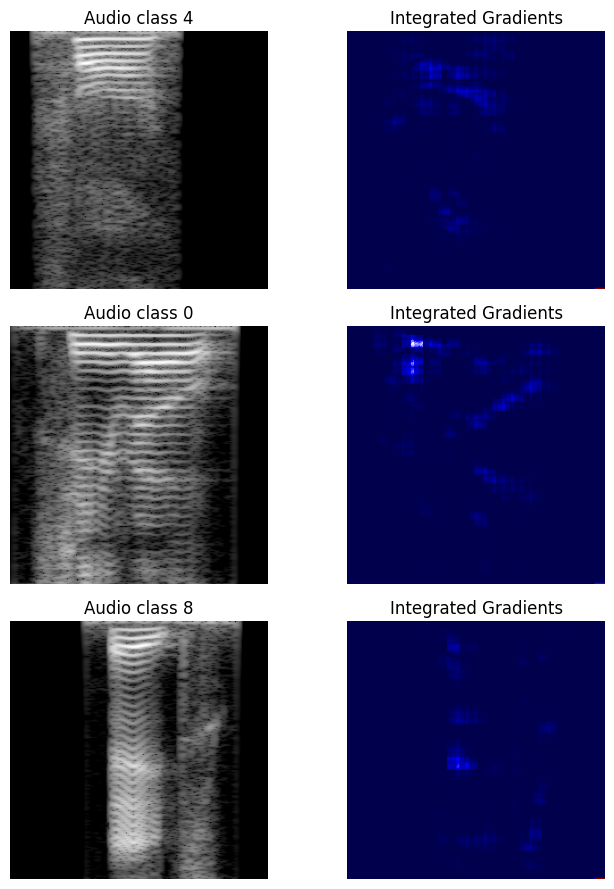

In [7]:
# Plot explanations
nr_images = 3
fig, axes = plt.subplots(nrows=nr_images, ncols=2, figsize=(nr_images * 2.5, int(nr_images * 3)))
for i, (x, y, a) in enumerate(zip(x_batch[:nr_images], y_predicted[:nr_images], a_batch_intgrad[:nr_images])):
    axes[i, 0].imshow(x.squeeze(), cmap='gray')
    axes[i, 0].set_title(f"Audio class {y}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(a, cmap="seismic")
    axes[i, 1].set_title(f"Integrated Gradients")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

In [8]:
init_kwargs = dict(
    disable_warnings=True,
    display_progressbar=True,
    abs=True,
    normalise=True,
    nr_samples=5,
    return_nan_when_prediction_changes=True,
)

call_kwargs = dict(
    model=model,
    x_batch=x_batch,
    y_batch=y_predicted,
    a_batch=a_batch_intgrad,
    explain_func=quantus.explain,
    explain_func_kwargs={"method": "IntegratedGradients"},
    channel_first=False,  # Change to False for TensorFlow
)

In [9]:
# MaxSensitivity
max_sen = quantus.MaxSensitivity(**init_kwargs)
scores_intgrad_maxs = max_sen(**call_kwargs)

# AverageSensitivity
avg_sen = quantus.AvgSensitivity(**init_kwargs)
scores_intgrad_avg_sen = avg_sen(**call_kwargs)

# Relative Input Stability
ris = quantus.RelativeInputStability(**init_kwargs)
ris_result = ris(**call_kwargs)

# Relative Output Stability
ros = quantus.RelativeOutputStability(**init_kwargs)
ros_result = ros(**call_kwargs)

# Relative Representation Stability
rrs = quantus.RelativeRepresentationStability(**init_kwargs)
rrs_result = rrs(**call_kwargs)

  0%|          | 0/1.0 [00:00<?, ?it/s]

ValueError: The layer sequential has never been called and thus has no defined input.

In [ ]:
# Assuming x_batch is your input data
dummy_input = tf.keras.Input(shape=x_batch.shape[1:])
model = tf.keras.Model(inputs=dummy_input, outputs=model(dummy_input))

In [10]:
class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def __call__(self, x):
        return self.model(x)

    def predict(self, x):
        return self.model.predict(x)

wrapped_model = ModelWrapper(model)

In [11]:
def custom_explain(model, inputs, targets, **kwargs):
    explanations = []
    for i in range(len(inputs)):
        with tf.GradientTape() as tape:
            tape.watch(inputs[i:i+1])
            prediction = model(inputs[i:i+1])
            loss = prediction[:, targets[i]]
        gradients = tape.gradient(loss, inputs[i:i+1])
        explanations.append(gradients.numpy().squeeze())
    return np.array(explanations)

In [12]:
call_kwargs = dict(
    model=wrapped_model,
    x_batch=x_batch,
    y_batch=y_predicted,
    a_batch=a_batch_intgrad,
    explain_func=custom_explain,
    explain_func_kwargs={},
    channel_first=False,
)

In [13]:
# Assuming 'model' is your original TensorFlow model
assert isinstance(model, tf.keras.Model), "The model should be a tf.keras.Model instance"

In [14]:
import tensorflow as tf
import numpy as np

def custom_explain(model, inputs, targets, **kwargs):
    explanations = []
    for i in range(len(inputs)):
        with tf.GradientTape() as tape:
            input_tensor = tf.convert_to_tensor(inputs[i:i+1], dtype=tf.float32)
            tape.watch(input_tensor)
            prediction = model(input_tensor)
            loss = prediction[:, targets[i]]
        gradients = tape.gradient(loss, input_tensor)
        explanations.append(gradients.numpy().squeeze())
    return np.array(explanations)


In [15]:
call_kwargs = dict(
    model=model,  # Use the original TensorFlow model
    x_batch=x_batch,
    y_batch=y_predicted,
    a_batch=None,  # We'll generate explanations on-the-fly
    explain_func=custom_explain,
    explain_func_kwargs={},
    channel_first=False,
)

In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import quantus
import traceback

class ModelWrapper(tf.keras.Model):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.activation = tf.keras.activations.linear  # Add this line

    def call(self, inputs):
        return self.model(inputs)

    def predict(self, x):
        return self.model.predict(x)

# Custom explain function
def custom_explain(model, inputs, targets, **kwargs):
    explanations = []
    for i in range(len(inputs)):
        with tf.GradientTape() as tape:
            input_tensor = tf.convert_to_tensor(inputs[i:i+1], dtype=tf.float32)
            tape.watch(input_tensor)
            prediction = model(input_tensor)
            loss = prediction[:, targets[i]]
        gradients = tape.gradient(loss, input_tensor)
        explanations.append(gradients.numpy().squeeze())
    return np.array(explanations)

# Wrap the model
wrapped_model = ModelWrapper(model)

# Ensure input shape is correct
x_batch = x_batch.reshape(-1, 227, 227, 1)

# Setup call_kwargs
call_kwargs = dict(
    model=wrapped_model,
    x_batch=x_batch,
    y_batch=y_predicted,
    a_batch=None,
    explain_func=custom_explain,
    explain_func_kwargs={},
    channel_first=False,
)

# Diagnostic prints
print("Model summary:")
wrapped_model.summary()

print("\nInput shape:")
print(x_batch.shape)

print("\nOutput shape:")
y_pred = wrapped_model.predict(x_batch)
print(y_pred.shape)

print("\nSample explanation:")
sample_explanation = custom_explain(wrapped_model, x_batch[:1], y_predicted[:1])
print(sample_explanation.shape)

print(f"\nTensorFlow version: {tf.__version__}")
print(f"Quantus version: {quantus.__version__}")

# Initialize metrics
init_kwargs = dict(
    disable_warnings=True,
    display_progressbar=True,
    abs=True,
    normalise=True,
    nr_samples=5,
    return_nan_when_prediction_changes=True,
)

metrics = [
    quantus.MaxSensitivity(**init_kwargs),
    quantus.AvgSensitivity(**init_kwargs),
    quantus.RelativeInputStability(**init_kwargs),
    quantus.RelativeOutputStability(**init_kwargs),
    quantus.RelativeRepresentationStability(**init_kwargs)
]

# Run metrics
results = {}
for metric in metrics:
    try:
        result = metric(**call_kwargs)
        if isinstance(result, (list, np.ndarray)) and len(result) > 0:
            results[metric.__class__.__name__] = result
        else:
            print(f"Warning: {metric.__class__.__name__} returned empty result")
    except Exception as e:
        print(f"Error running {metric.__class__.__name__}:")
        print(traceback.format_exc())

# Compile and display results
if not results:
    print("No metrics were successfully executed. Please check the error messages above.")
else:
    df_results = pd.DataFrame(results)
    summary = df_results.agg([np.mean, np.std])
    print("\nResults summary:")
    print(summary)

Model summary:


Model: "model_wrapper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 10)             │    14,222,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,222,026 (54.25 MB)

 Trainable params: 14,222,026 (54.25 MB)

...

Error running RelativeInputStability:
Traceback (most recent call last):
  File "/tmp/ipykernel_3624122/2175029119.py", line 90, in <module>
    result = metric(**call_kwargs)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/robustness/relative_input_stability.py", line 211, in __call__
    return super().__call__(
           ^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/base.py", line 290, in __call__
    result = self.evaluate_batch(**data_batch)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/robustness/relative_input_stability.py", line 328, in evaluate_batch
    changed_prediction_indices = self.changed_prediction_indices_func(
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/helpers

  0%|          | 0/1.0 [00:00<?, ?it/s]


Error running RelativeOutputStability:
Traceback (most recent call last):
  File "/tmp/ipykernel_3624122/2175029119.py", line 90, in <module>
    result = metric(**call_kwargs)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/robustness/relative_output_stability.py", line 216, in __call__
    return super().__call__(
           ^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/base.py", line 290, in __call__
    result = self.evaluate_batch(**data_batch)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/robustness/relative_output_stability.py", line 313, in evaluate_batch
    logits = model.predict(x_batch)
             ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/helpers/model/tf_model.py", line 180, in predict
    predict_model = self.

/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/helpers/model/tf_model.py:289: UserWarning: quantus.TensorFlowModel.get_hidden_layers_representations(...) received `layer_names`=None and `layer_indices`=None. This will force creation of tensorflow.keras.Model with outputs of each layer from original model. This can be very computationally expensive.
  warn(
  0%|          | 0/1.0 [00:00<?, ?it/s]

Error running RelativeRepresentationStability:
Traceback (most recent call last):
  File "/tmp/ipykernel_3624122/2175029119.py", line 90, in <module>
    result = metric(**call_kwargs)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/robustness/relative_representation_stability.py", line 226, in __call__
    return super().__call__(
           ^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/base.py", line 290, in __call__
    result = self.evaluate_batch(**data_batch)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/metrics/robustness/relative_representation_stability.py", line 324, in evaluate_batch
    internal_representations = model.get_hidden_representations(
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/